Train observations before January 2025: 96,432
Test window: 2025-01-01 00:00 to 2025-01-31 23:00
Test observations evaluated: 744
Last evaluated timestamp: 2025-01-31 23:00
Seasonal period: 24 hours
MAE: 4.1469 pm2_5 (μg/m³)
MAE (% of mean): 45.34%
MSE: 33.3596 (pm2_5 (μg/m³))²
MSE (% of mean²): 39.88%
RMSE: 5.7758 pm2_5 (μg/m³)
RMSE (% of mean): 63.15%
R²: 0.1425
Actual test mean: 9.1461 pm2_5 (μg/m³)
Actual test std: 6.2416 pm2_5 (μg/m³)


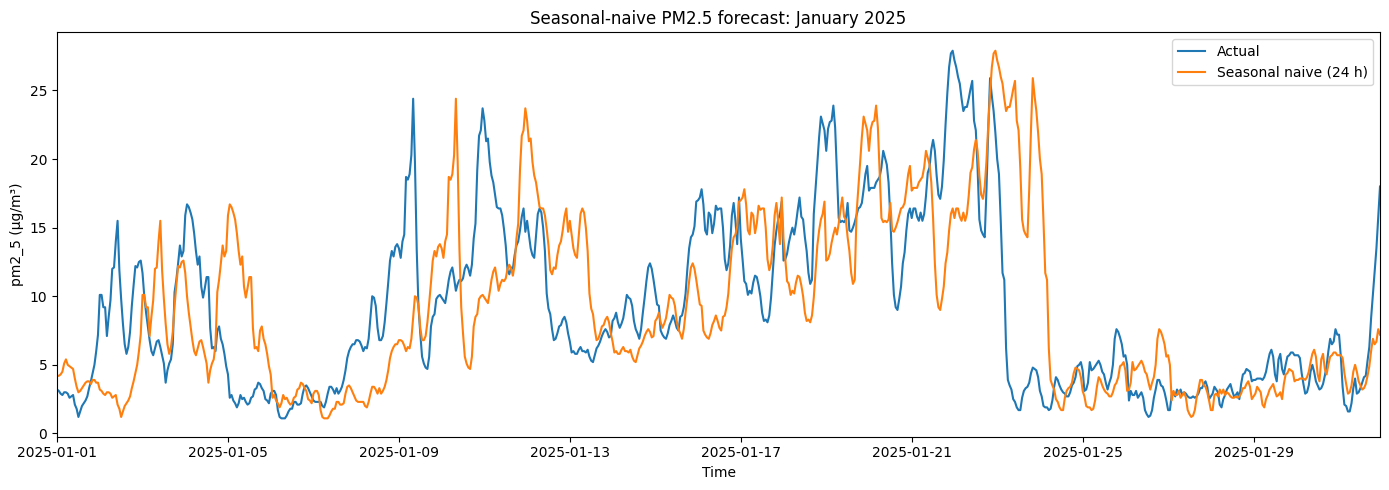

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


DATA_PATH = Path("online_data/air_qual/air_qual.csv")
TARGET_COL = "pm2_5 (μg/m³)"
SEASONAL_PERIOD = 24  # one day for hourly data
TEST_START = pd.Timestamp("2025-01-01 00:00:00")
TEST_END = pd.Timestamp("2025-01-31 23:00:00")


# Load and regularize the hourly target series.
data = pd.read_csv(DATA_PATH)
data["time"] = pd.to_datetime(data["time"], errors="coerce")
data[TARGET_COL] = pd.to_numeric(data[TARGET_COL], errors="coerce")
series = (
    data.dropna(subset=["time", TARGET_COL])
    .sort_values("time")
    .drop_duplicates(subset="time")
    .set_index("time")[TARGET_COL]
    .resample("h")
    .mean()
)

train_series = series.loc[series.index < TEST_START]
test_series = series[(series.index >= TEST_START) & (series.index <= TEST_END)]
if test_series.empty:
    raise ValueError("No observations found in the January 2025 test window.")

# Seasonal-naive forecast: each value uses the observation 24 hours earlier.
actual = test_series
forecast = series.shift(SEASONAL_PERIOD).loc[test_series.index]
valid = actual.notna() & forecast.notna()
actual = actual[valid]
forecast = forecast[valid]
if actual.empty:
    raise ValueError("No valid January 2025 observations have a 24-hour lag.")

mae = mean_absolute_error(actual, forecast)
mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
r2 = r2_score(actual, forecast)
actual_mean = actual.mean()
mae_percent = 100 * mae / actual_mean
mse_percent = 100 * mse / (actual_mean ** 2)
rmse_percent = 100 * rmse / actual_mean

print(f"Train observations before January 2025: {len(train_series):,}")
print(f"Test window: {TEST_START:%Y-%m-%d %H:%M} to {TEST_END:%Y-%m-%d %H:%M}")
print(f"Test observations evaluated: {len(actual):,}")
print(f"Last evaluated timestamp: {actual.index.max():%Y-%m-%d %H:%M}")
print(f"Seasonal period: {SEASONAL_PERIOD} hours")
print(f"MAE: {mae:.4f} {TARGET_COL}")
print(f"MAE (% of mean): {mae_percent:.2f}%")
print(f"MSE: {mse:.4f} ({TARGET_COL})²")
print(f"MSE (% of mean²): {mse_percent:.2f}%")
print(f"RMSE: {rmse:.4f} {TARGET_COL}")
print(f"RMSE (% of mean): {rmse_percent:.2f}%")
print(f"R²: {r2:.4f}")
print(f"Actual test mean: {actual_mean:.4f} {TARGET_COL}")
print(f"Actual test std: {actual.std():.4f} {TARGET_COL}")

plt.figure(figsize=(14, 5))
plt.plot(actual, label="Actual", linewidth=1.5)
plt.plot(forecast, label="Seasonal naive (24 h)", linewidth=1.5)
plt.title("Seasonal-naive PM2.5 forecast: January 2025")
plt.xlabel("Time")
plt.ylabel(TARGET_COL)
plt.xlim(TEST_START, TEST_END)
plt.legend()
plt.tight_layout()
plt.show()